In [2]:
import os
import json
import math
from pathlib import Path
from typing import List, Dict, Any, Tuple

import jax
import jax.numpy as jnp
from jax import vmap

import numpy as onp
import matplotlib
import matplotlib.pyplot as plt

import torch
from tqdm.auto import tqdm

print("JAX backend:", jax.default_backend())
print("All devices:", jax.devices())

if len(jax.devices("gpu")) > 0:
    JAX_DEVICE = jax.devices("gpu")[0]
else:
    JAX_DEVICE = jax.devices("cpu")[0]
print("Active JAX device:", JAX_DEVICE)

if torch.cuda.is_available():
    TORCH_DEVICE = torch.device("cuda")
else:
    TORCH_DEVICE = torch.device("cpu")
print("Active PyTorch device:", TORCH_DEVICE)

JAX backend: gpu
All devices: [CudaDevice(id=0)]
Active JAX device: cuda:0
Active PyTorch device: cuda


In [3]:
# ----------------------------
# Hyperparameters and paths
# ----------------------------
ROOT = Path.cwd()

SEED = 421

# Architecture / data
D_IN = 5
D_OUT = 5
WIDTH = 100
TRAIN_SIZE = 100
TEST_SIZE = 100
TEACHER_SEED = 0
STUDENT_SEED = 1
TEACHER_ALPHA = 1.0

# Optimization
STEPS = 100_000
ETA = 0.1
CHECKPOINT_EVERY = 100
THRESHOLD = 1e-3

# ----------------------------
# Numerical dtype
# ----------------------------
NUMERICAL_DTYPE = "float64"

if NUMERICAL_DTYPE == "float64":
    jax.config.update("jax_enable_x64", True)
    DEFAULT_DTYPE = jnp.float64
    LINALG_DTYPE = jnp.float64
    TORCH_DTYPE = torch.float64
else:
    jax.config.update("jax_enable_x64", False)
    DEFAULT_DTYPE = jnp.float32
    LINALG_DTYPE = jnp.float32
    TORCH_DTYPE = torch.float32

JAC_CHUNK_SIZE = 100
DIAG_DELTA = 1
K_ACTIVE_DEFAULT = 500
DIAG_N_SUB = 100

onp.random.seed(SEED)
torch.manual_seed(SEED)

print("Numerical dtype:", NUMERICAL_DTYPE)

Numerical dtype: float64


In [ ]:
# Shared format for images

def setup_notebook_style() -> None:
    matplotlib.rcParams.update(
        {
            "font.family": "serif",
            "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
            "mathtext.fontset": "stix",
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "axes.linewidth": 1.5,
            "xtick.major.width": 1.5,
            "ytick.major.width": 1.5,
            "font.size": 14,
            "axes.titlesize": 16,
            "axes.labelsize": 14,
            "xtick.labelsize": 14,
            "ytick.labelsize": 14,
            "legend.fontsize": 14,
        }
    )

def set_spine_width(ax, lw: float = 1.5) -> None:
    for spine in ax.spines.values():
        spine.set_linewidth(lw)

setup_notebook_style()

## How to generate the three canonical runs

Open `running_saving_template.ipynb` and run it once for each configuration below. Each run creates its own subdirectory under `benchmarks/omnigrok_regression/` and `results/omnigrok_regression/`.

1. **With weight decay, alpha = 2**
   - `STUDENT_ALPHA = 2.0`
   - `LAMBDA_REG = 1e-4`

2. **Without weight decay, alpha = 2**
   - `STUDENT_ALPHA = 2.0`
   - `LAMBDA_REG = 0.0`

3. **With weight decay, alpha = 3**
   - `STUDENT_ALPHA = 3.0`
   - `LAMBDA_REG = 1e-4`

After the three runs finish, return to this notebook and execute the cells below to reproduce all figures.

In [5]:
def make_run_id(student_alpha: float, lambda_reg: float) -> str:
    return (
        f"din{D_IN}_dout{D_OUT}_w{WIDTH}_nt{TRAIN_SIZE}_alpha{student_alpha}_"
        f"steps{STEPS}_eta{ETA}_reg{lambda_reg}_seed{STUDENT_SEED}"
    )

def run_paths(student_alpha: float, lambda_reg: float):
    run_id = make_run_id(student_alpha, lambda_reg)
    benchmark_dir = ROOT / "benchmarks" / "omnigrok_regression" / run_id
    result_dir = ROOT / "results" / "omnigrok_regression" / run_id
    return benchmark_dir, result_dir

RUN_CFG = {
    "wd_alpha2": (2.0, 1e-4),
    "noWD_alpha2": (2.0, 0.0),
    "wd_alpha3": (3.0, 1e-4),
}

for key, (alpha, lam) in RUN_CFG.items():
    bd, rd = run_paths(alpha, lam)
    print(key, ":", rd.name)
    print("  exists:", rd.exists() and (rd / "training_history.pt").exists())

wd_alpha2 : din5_dout5_w100_nt100_alpha2.0_steps100000_eta0.1_reg0.0001_seed1
  exists: True
noWD_alpha2 : din5_dout5_w100_nt100_alpha2.0_steps100000_eta0.1_reg0.0_seed1
  exists: True
wd_alpha3 : din5_dout5_w100_nt100_alpha3.0_steps100000_eta0.1_reg0.0001_seed1
  exists: True


In [6]:
def torch_to_jax(t, dtype=DEFAULT_DTYPE):
    """Convert a PyTorch tensor or NumPy array to a JAX array on the active device."""
    if hasattr(t, "numpy"):
        t = t.detach().cpu().numpy()
    return jax.device_put(jnp.array(t, dtype=dtype), JAX_DEVICE)


def load_checkpoint_to_jax(path: Path):
    """Load a PyTorch MLP checkpoint into a nested JAX pytree."""
    state = torch.load(path, map_location="cpu", weights_only=False)
    return {
        "l1": {"W": torch_to_jax(state["l1.weight"]), "b": torch_to_jax(state["l1.bias"])},
        "l2": {"W": torch_to_jax(state["l2.weight"]), "b": torch_to_jax(state["l2.bias"])},
        "l3": {"W": torch_to_jax(state["l3.weight"]), "b": torch_to_jax(state["l3.bias"])},
    }


def predict(params, x):
    """Prediction for a single input x (shape (d_in,)). Output shape (d_out,)."""
    x = jnp.tanh(params["l1"]["W"] @ x + params["l1"]["b"])
    x = jnp.tanh(params["l2"]["W"] @ x + params["l2"]["b"])
    return params["l3"]["W"] @ x + params["l3"]["b"]


def predict_batch(params, X):
    return vmap(lambda x: predict(params, x))(X)


def compute_jacobian_chunk(params, X_chunk):
    jac_fn = jax.jacrev(lambda p, x: predict(p, x))
    jac_pytree = vmap(jac_fn, in_axes=(None, 0))(params, X_chunk)
    leaves = jax.tree_util.tree_leaves(jac_pytree)
    flat = jnp.concatenate([jnp.reshape(leaf, (X_chunk.shape[0] * D_OUT, -1)) for leaf in leaves], axis=1)
    return flat.astype(DEFAULT_DTYPE)


def compute_jacobian(params, X, chunk_size: int = JAC_CHUNK_SIZE):
    rows = []
    for i in range(0, X.shape[0], chunk_size):
        rows.append(compute_jacobian_chunk(params, X[i:i + chunk_size]))
    return jnp.concatenate(rows, axis=0)


def compute_ntk(J):
    """Compute K = J @ J^T"""
    J_linalg = J.astype(LINALG_DTYPE)
    return J_linalg @ J_linalg.T


def compute_V_k(J, K, k: int):
    """Top-k right singular vectors of J using K = J J^T"""
    K_linalg = K.astype(LINALG_DTYPE)
    eigvals, eigvecs = jnp.linalg.eigh(K_linalg)
    eigvals = jnp.clip(eigvals, 1e-10, None)
    idx = jnp.argsort(eigvals)[::-1][:k]
    lam_k = eigvals[idx]
    U_k = eigvecs[:, idx]
    sigma_k = jnp.sqrt(lam_k)
    J_linalg = J.astype(LINALG_DTYPE)
    V_k = (J_linalg.T @ U_k) / sigma_k
    return V_k.astype(DEFAULT_DTYPE)


def get_subset(X, n_sub: int, key):
    if n_sub >= X.shape[0]:
        return X
    perm = jax.random.permutation(key, X.shape[0])
    return X[perm[:n_sub]]


def cell_key(offset: int):
    return jax.random.PRNGKey(SEED + offset)


def sorted_checkpoints(result_dir: Path):
    paths = sorted(
        [p for p in result_dir.glob("checkpoint_step_*.pt")],
        key=lambda p: int(p.stem.split("_")[-1])
    )
    return paths


def compute_streaming_diagnostics(checkpoint_paths, X_diag, k_active=K_ACTIVE_DEFAULT, delta=DIAG_DELTA):
    """Return (steps, D_t, E_t, C_t) arrays from consecutive checkpoints."""
    D, E, C = [], [], []
    step_list = []

    params_prev = load_checkpoint_to_jax(checkpoint_paths[0])
    J_prev = compute_jacobian(params_prev, X_diag, JAC_CHUNK_SIZE).astype(LINALG_DTYPE)
    K_prev = compute_ntk(J_prev)
    V_prev = compute_V_k(J_prev, K_prev, k_active).astype(LINALG_DTYPE)

    for idx in range(delta, len(checkpoint_paths), delta):
        path = checkpoint_paths[idx]
        step = int(path.stem.split("_")[-1])
        params_curr = load_checkpoint_to_jax(path)
        J_curr = compute_jacobian(params_curr, X_diag, JAC_CHUNK_SIZE).astype(LINALG_DTYPE)
        K_curr = compute_ntk(J_curr)

        D.append(jnp.linalg.norm(K_curr - K_prev) / jnp.linalg.norm(K_prev))
        C.append(
            jnp.linalg.norm(K_prev @ K_curr - K_curr @ K_prev)
            / (jnp.linalg.norm(K_prev) * jnp.linalg.norm(K_curr))
        )

        V_curr = compute_V_k(J_curr, K_curr, k_active).astype(LINALG_DTYPE)
        overlap = jnp.linalg.norm(V_prev.T @ V_curr) ** 2
        drift = jnp.sqrt(jnp.maximum(0.0, 1.0 - overlap / k_active))
        E.append(drift)
        step_list.append(step)

        V_prev = V_curr
        K_prev = K_curr
        del J_curr, params_curr

    return onp.array(step_list), onp.array(D), onp.array(E), onp.array(C)


def compute_E_vs_k(state_a, state_b, X_sub, k_active=K_ACTIVE_DEFAULT):
    """Active-plane drift E_active(k) between two states."""
    J_a = compute_jacobian(state_a, X_sub, JAC_CHUNK_SIZE)
    K_a = compute_ntk(J_a)
    V_a_full = compute_V_k(J_a, K_a, k_active)
    del J_a, K_a

    J_b = compute_jacobian(state_b, X_sub, JAC_CHUNK_SIZE)
    K_b = compute_ntk(J_b)
    V_b_full = compute_V_k(J_b, K_b, k_active)
    del J_b, K_b

    k_max = min(k_active, V_a_full.shape[1])
    k_values = list(range(1, k_max + 1))
    E_vs_k = []
    for k in k_values:
        V_a_k = V_a_full[:, :k]
        V_b_k = V_b_full[:, :k]
        overlap = jnp.linalg.norm(V_a_k.T @ V_b_k) ** 2
        drift = jnp.sqrt(jnp.maximum(0.0, 1.0 - overlap / k))
        E_vs_k.append(float(drift))
    return k_values, onp.array(E_vs_k)


def first_step_at_or_above(steps, values, level):
    idx = onp.flatnonzero(values >= level)
    return None if len(idx) == 0 else int(steps[idx[0]])


def load_run(student_alpha: float, lambda_reg: float, compute_diag: bool = True):
    """Load a run and optionally compute streaming diagnostics."""
    benchmark_dir, result_dir = run_paths(student_alpha, lambda_reg)
    history = torch.load(result_dir / "training_history.pt", map_location="cpu", weights_only=False)

    out = {
        "benchmark_dir": benchmark_dir,
        "result_dir": result_dir,
        "student_alpha": student_alpha,
        "lambda_reg": lambda_reg,
        "steps_gd": onp.asarray(history["step"]),
        "train_loss": onp.asarray(history["train_loss"]),
        "test_loss": onp.asarray(history["test_loss"]),
        "train_acc": onp.asarray(history["train_acc"]),
        "test_acc": onp.asarray(history["test_acc"]),
        "l2_sq": onp.asarray(history["l2_sq"]),
    }

    checkpoint_paths = sorted_checkpoints(result_dir)
    out["checkpoint_paths"] = checkpoint_paths

    X_train_jax = torch_to_jax(torch.load(benchmark_dir / "X_train.pt", map_location="cpu"))
    out["X_train_jax"] = X_train_jax

    if compute_diag:
        X_diag = get_subset(X_train_jax, DIAG_N_SUB, cell_key(1))
        diag_steps, D_t, E_t, C_t = compute_streaming_diagnostics(checkpoint_paths, X_diag)
        out["diag_steps"] = diag_steps
        out["D_t"] = D_t
        out["E_t"] = E_t
        out["C_t"] = C_t
        print(f"Run alpha={student_alpha} reg={lambda_reg}: D_t range [{D_t.min():.4f}, {D_t.max():.4f}]")
        print(f"  E_t range [{E_t.min():.4f}, {E_t.max():.4f}], C_t range [{C_t.min():.4f}, {C_t.max():.4f}]")

    return out

In [7]:
# Load the three canonical runs
runs = {}
for key, (alpha, lam) in RUN_CFG.items():
    print(f"\nLoading {key} ...")
    runs[key] = load_run(alpha, lam, compute_diag=True)


Loading wd_alpha2 ...
Run alpha=2.0 reg=0.0001: D_t range [0.0012, 0.0700]
  E_t range [0.0009, 0.2516], C_t range [0.0000, 0.0041]

Loading noWD_alpha2 ...
Run alpha=2.0 reg=0.0: D_t range [0.0000, 0.0688]
  E_t range [0.0000, 0.2517], C_t range [0.0000, 0.0041]

Loading wd_alpha3 ...
Run alpha=3.0 reg=0.0001: D_t range [0.0009, 0.1220]
  E_t range [0.0009, 0.4025], C_t range [0.0000, 0.0115]


In [8]:
# 95% accuracy milestones (used for vertical reference lines)
milestones = {}
for key, run in runs.items():
    milestones[key] = {
        "train_95": first_step_at_or_above(run["steps_gd"], run["train_acc"], 0.95),
        "test_95": first_step_at_or_above(run["steps_gd"], run["test_acc"], 0.95),
    }
    print(key, milestones[key])

wd_alpha2 {'train_95': 1400, 'test_95': 50200}
noWD_alpha2 {'train_95': 1400, 'test_95': None}
wd_alpha3 {'train_95': 1800, 'test_95': 91600}


## Figure 2: with/without weight decay

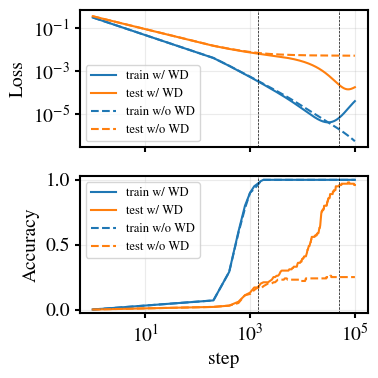

In [9]:
# Figure 2, panel (a): losses and accuracy
run_wd = runs["wd_alpha2"]
run_noWD = runs["noWD_alpha2"]

plot_steps = onp.maximum(run_wd["steps_gd"], 1)

fig, axes = plt.subplots(2, 1, figsize=(4, 4), sharex=True)
for ax in axes:
    set_spine_width(ax)

axes[0].semilogy(plot_steps, run_wd["train_loss"], color="C0", label="train w/ WD")
axes[0].semilogy(plot_steps, run_wd["test_loss"], color="C1", label="test w/ WD")
axes[0].semilogy(plot_steps, run_noWD["train_loss"], color="C0", linestyle="--", label="train w/o WD")
axes[0].semilogy(plot_steps, run_noWD["test_loss"], color="C1", linestyle="--", label="test w/o WD")
for label, m in milestones["wd_alpha2"].items():
    if m is not None:
        axes[0].axvline(m, color="black", linestyle="--", linewidth=0.5)
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

axes[1].plot(plot_steps, run_wd["train_acc"], color="C0", label="train w/ WD")
axes[1].plot(plot_steps, run_wd["test_acc"], color="C1", label="test w/ WD")
axes[1].plot(plot_steps, run_noWD["train_acc"], color="C0", linestyle="--", label="train w/o WD")
axes[1].plot(plot_steps, run_noWD["test_acc"], color="C1", linestyle="--", label="test w/o WD")
for label, m in milestones["wd_alpha2"].items():
    if m is not None:
        axes[1].axvline(m, color="black", linestyle="--", linewidth=0.5)
axes[1].set_xscale("log")
axes[1].set_ylim(-0.03, 1.03)
axes[1].set_xlabel("step")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

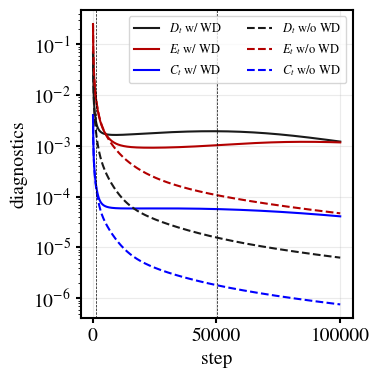

In [10]:
# Figure 2, panel (b): diagnostics
fig, ax = plt.subplots(figsize=(4, 4))
set_spine_width(ax)

ds = run_wd["diag_steps"]
ax.plot(ds, run_wd["D_t"], color="0.1", linestyle="-", label="$D_t$ w/ WD")
ax.plot(ds, run_wd["E_t"], color=(0.7, 0., 0.), linestyle="-", label="$E_t$ w/ WD")
ax.plot(ds, run_wd["C_t"], color="blue", linestyle="-", label="$C_t$ w/ WD")
ax.plot(ds, run_noWD["D_t"], color="0.1", linestyle="--", label="$D_t$ w/o WD")
ax.plot(ds, run_noWD["E_t"], color=(0.7, 0., 0.), linestyle="--", label="$E_t$ w/o WD")
ax.plot(ds, run_noWD["C_t"], color="blue", linestyle="--", label="$C_t$ w/o WD")

for label, m in milestones["wd_alpha2"].items():
    if m is not None:
        ax.axvline(m, color="black", linestyle="--", linewidth=0.5)

ax.set_xlabel("step")
ax.set_ylabel("diagnostics")
ax.set_yscale("log")
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

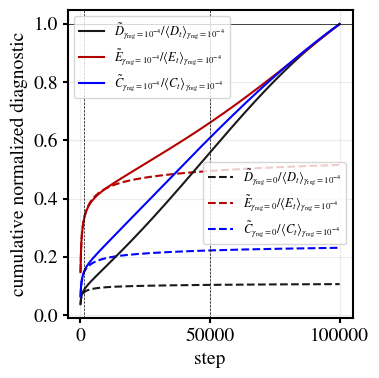

In [11]:
# Figure 2, panel (c): cumulative normalized diagnostics
num_checkpoints = len(run_wd["checkpoint_paths"])

D_norm_WD = run_wd["D_t"] / onp.mean(run_wd["D_t"])
E_norm_WD = run_wd["E_t"] / onp.mean(run_wd["E_t"])
C_norm_WD = run_wd["C_t"] / onp.mean(run_wd["C_t"])

D_norm_noWD = run_noWD["D_t"] / onp.mean(run_wd["D_t"])
E_norm_noWD = run_noWD["E_t"] / onp.mean(run_wd["E_t"])
C_norm_noWD = run_noWD["C_t"] / onp.mean(run_wd["C_t"])

D_cum_WD = onp.cumsum(D_norm_WD) / num_checkpoints
E_cum_WD = onp.cumsum(E_norm_WD) / num_checkpoints
C_cum_WD = onp.cumsum(C_norm_WD) / num_checkpoints
D_cum_noWD = onp.cumsum(D_norm_noWD) / num_checkpoints
E_cum_noWD = onp.cumsum(E_norm_noWD) / num_checkpoints
C_cum_noWD = onp.cumsum(C_norm_noWD) / num_checkpoints

fig, ax = plt.subplots(figsize=(4, 4))
set_spine_width(ax)

line_D_noWD, = ax.plot(run_wd["diag_steps"], D_cum_noWD, color="0.1", linestyle="--")
line_E_noWD, = ax.plot(run_wd["diag_steps"], E_cum_noWD, color=(0.7, 0., 0.), linestyle="--")
line_C_noWD, = ax.plot(run_wd["diag_steps"], C_cum_noWD, color="blue", linestyle="--")
line_D_wd, = ax.plot(run_wd["diag_steps"], D_cum_WD, color="0.1", linestyle="-")
line_E_wd, = ax.plot(run_wd["diag_steps"], E_cum_WD, color=(0.7, 0., 0.), linestyle="-")
line_C_wd, = ax.plot(run_wd["diag_steps"], C_cum_WD, color="blue", linestyle="-")

ax.set_xlabel("step")
ax.set_ylabel("cumulative normalized diagnostic")

legend1 = ax.legend(
    [line_D_noWD, line_E_noWD, line_C_noWD],
    ["$\\tilde{D}_{\\gamma_{\\rm reg}=0} / \\langle D_t \\rangle_{\\gamma_{\\rm reg}=10^{-4}}$",
     "$\\tilde{E}_{\\gamma_{\\rm reg}=0} / \\langle E_t \\rangle_{\\gamma_{\\rm reg}=10^{-4}}$",
     "$\\tilde{C}_{\\gamma_{\\rm reg}=0} / \\langle C_t \\rangle_{\\gamma_{\\rm reg}=10^{-4}}$"],
    loc="lower right", bbox_to_anchor=(1.0, 0.22), fontsize=9
)
legend2 = ax.legend(
    [line_D_wd, line_E_wd, line_C_wd],
    ["$\\tilde{D}_{\\gamma_{\\rm reg}=10^{-4}} / \\langle D_t \\rangle_{\\gamma_{\\rm reg}=10^{-4}}$",
     "$\\tilde{E}_{\\gamma_{\\rm reg}=10^{-4}} / \\langle E_t \\rangle_{\\gamma_{\\rm reg}=10^{-4}}$",
     "$\\tilde{C}_{\\gamma_{\\rm reg}=10^{-4}} / \\langle C_t \\rangle_{\\gamma_{\\rm reg}=10^{-4}}$"],
    loc="upper left", fontsize=9
)
ax.add_artist(legend1)

ax.axhline(1, color="black", linestyle="-", linewidth=0.5)
for label, m in milestones["wd_alpha2"].items():
    if m is not None:
        ax.axvline(m, color="black", linestyle="--", linewidth=0.5)

ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Figure 3: alpha = 2 vs alpha = 3 (both with WD)

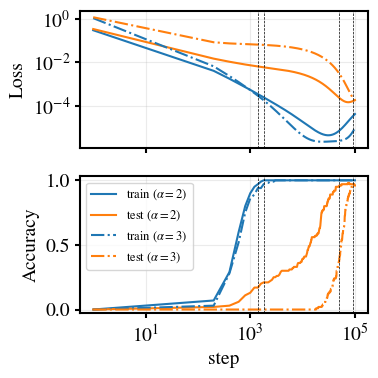

In [12]:
# Figure 3, panel (a): losses and accuracy
run_a2 = runs["wd_alpha2"]
run_a3 = runs["wd_alpha3"]

plot_steps = onp.maximum(run_a2["steps_gd"], 1)

fig, axes = plt.subplots(2, 1, figsize=(4, 4), sharex=True)
for ax in axes:
    set_spine_width(ax)

axes[0].semilogy(plot_steps, run_a2["train_loss"], color="C0")
axes[0].semilogy(plot_steps, run_a2["test_loss"], color="C1")
axes[0].semilogy(plot_steps, run_a3["train_loss"], color="C0", linestyle="-.")
axes[0].semilogy(plot_steps, run_a3["test_loss"], color="C1", linestyle="-.")
for key in ["wd_alpha2", "wd_alpha3"]:
    for label, m in milestones[key].items():
        if m is not None:
            axes[0].axvline(m, color="black", linestyle="--", linewidth=0.5)
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)

axes[1].plot(plot_steps, run_a2["train_acc"], color="C0", label="train ($\\alpha=2$)")
axes[1].plot(plot_steps, run_a2["test_acc"], color="C1", label="test ($\\alpha=2$)")
axes[1].plot(plot_steps, run_a3["train_acc"], color="C0", linestyle="-.", label="train ($\\alpha=3$)")
axes[1].plot(plot_steps, run_a3["test_acc"], color="C1", linestyle="-.", label="test ($\\alpha=3$)")
for key in ["wd_alpha2", "wd_alpha3"]:
    for label, m in milestones[key].items():
        if m is not None:
            axes[1].axvline(m, color="black", linestyle="--", linewidth=0.5)
axes[1].set_xscale("log")
axes[1].set_ylim(-0.03, 1.03)
axes[1].set_xlabel("step")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

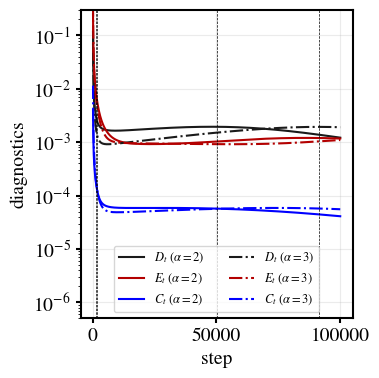

In [13]:
# Figure 3, panel (b): diagnostics
fig, ax = plt.subplots(figsize=(4, 4))
set_spine_width(ax)

ds = run_a2["diag_steps"]
ax.plot(ds, run_a2["D_t"], color="0.1", linestyle="-", label="$D_t~(\\alpha=2)$")
ax.plot(ds, run_a2["E_t"], color=(0.7, 0., 0.), linestyle="-", label="$E_t~(\\alpha=2)$")
ax.plot(ds, run_a2["C_t"], color="blue", linestyle="-", label="$C_t~(\\alpha=2)$")
ax.plot(ds, run_a3["D_t"], color="0.1", linestyle="-.", label="$D_t~(\\alpha=3)$")
ax.plot(ds, run_a3["E_t"], color=(0.7, 0., 0.), linestyle="-.", label="$E_t~(\\alpha=3)$")
ax.plot(ds, run_a3["C_t"], color="blue", linestyle="-.", label="$C_t~(\\alpha=3)$")

for key in ["wd_alpha2", "wd_alpha3"]:
    for label, m in milestones[key].items():
        if m is not None:
            ax.axvline(m, color="black", linestyle="--", linewidth=0.5)

ax.set_xlabel("step")
ax.set_ylabel("diagnostics")
ax.set_yscale("log")
ax.set_ylim(5e-7, 3e-1)
ax.legend(ncol=2, fontsize=9)
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

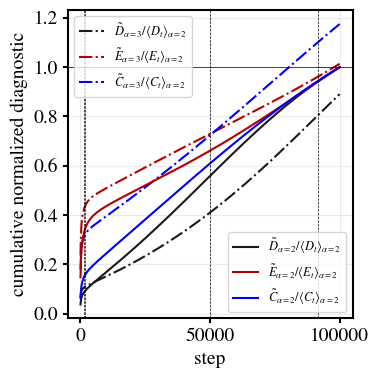

In [14]:
# Figure 3, panel (c): cumulative normalized diagnostics
num_checkpoints = len(run_a2["checkpoint_paths"])

D_norm_a2 = run_a2["D_t"] / onp.mean(run_a2["D_t"])
E_norm_a2 = run_a2["E_t"] / onp.mean(run_a2["E_t"])
C_norm_a2 = run_a2["C_t"] / onp.mean(run_a2["C_t"])

D_norm_a3 = run_a3["D_t"] / onp.mean(run_a2["D_t"])
E_norm_a3 = run_a3["E_t"] / onp.mean(run_a2["E_t"])
C_norm_a3 = run_a3["C_t"] / onp.mean(run_a2["C_t"])

D_cum_a2 = onp.cumsum(D_norm_a2) / num_checkpoints
E_cum_a2 = onp.cumsum(E_norm_a2) / num_checkpoints
C_cum_a2 = onp.cumsum(C_norm_a2) / num_checkpoints
D_cum_a3 = onp.cumsum(D_norm_a3) / num_checkpoints
E_cum_a3 = onp.cumsum(E_norm_a3) / num_checkpoints
C_cum_a3 = onp.cumsum(C_norm_a3) / num_checkpoints

fig, ax = plt.subplots(figsize=(4, 4))
set_spine_width(ax)

line_D_a3, = ax.plot(ds, D_cum_a3, color="0.1", linestyle="-.")
line_E_a3, = ax.plot(ds, E_cum_a3, color=(0.7, 0., 0.), linestyle="-.")
line_C_a3, = ax.plot(ds, C_cum_a3, color="blue", linestyle="-.")
line_D_a2, = ax.plot(ds, D_cum_a2, color="0.1", linestyle="-")
line_E_a2, = ax.plot(ds, E_cum_a2, color=(0.7, 0., 0.), linestyle="-")
line_C_a2, = ax.plot(ds, C_cum_a2, color="blue", linestyle="-")

ax.set_xlabel("step")
ax.set_ylabel("cumulative normalized diagnostic")

legend1 = ax.legend(
    [line_D_a3, line_E_a3, line_C_a3],
    ["$\\tilde{D}_{\\alpha=3} / \\langle D_t \\rangle_{\\alpha=2}$",
     "$\\tilde{E}_{\\alpha=3} / \\langle E_t \\rangle_{\\alpha=2}$",
     "$\\tilde{C}_{\\alpha=3} / \\langle C_t \\rangle_{\\alpha=2}$"],
    loc="upper left", fontsize=9
)
legend2 = ax.legend(
    [line_D_a2, line_E_a2, line_C_a2],
    ["$\\tilde{D}_{\\alpha=2} / \\langle D_t \\rangle_{\\alpha=2}$",
     "$\\tilde{E}_{\\alpha=2} / \\langle E_t \\rangle_{\\alpha=2}$",
     "$\\tilde{C}_{\\alpha=2} / \\langle C_t \\rangle_{\\alpha=2}$"],
    loc="lower right", fontsize=9
)
ax.add_artist(legend1)

ax.axhline(1, color="black", linestyle="-", linewidth=0.5)
for key in ["wd_alpha2", "wd_alpha3"]:
    for label, m in milestones[key].items():
        if m is not None:
            ax.axvline(m, color="black", linestyle="--", linewidth=0.5)

ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Appendix figures

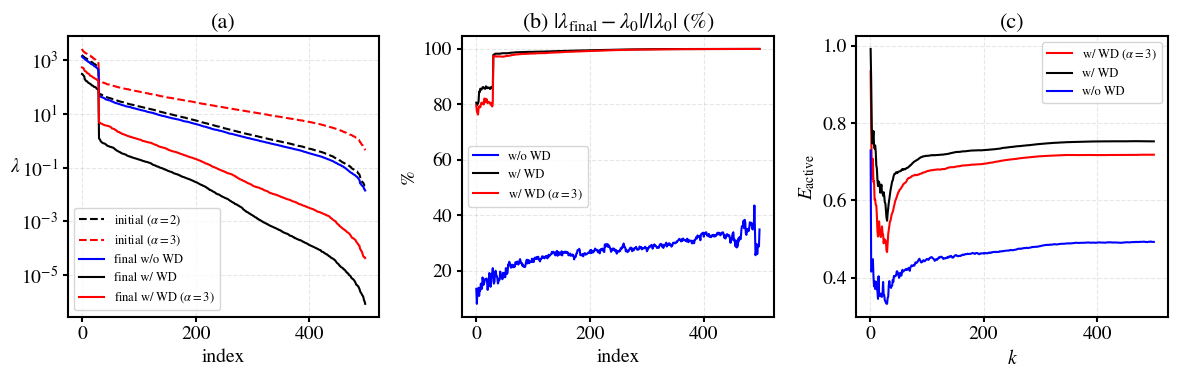

In [15]:
# Appendix Figure 4: eigenvalue comparison (3 panels in one figure)
X_sub_full = get_subset(run_a2["X_train_jax"], DIAG_N_SUB, cell_key(2))

spectra = {}
for key, run in runs.items():
    state_0 = load_checkpoint_to_jax(run["checkpoint_paths"][0])
    state_final = load_checkpoint_to_jax(run["checkpoint_paths"][-1])

    J_0 = compute_jacobian(state_0, X_sub_full, JAC_CHUNK_SIZE)
    K_0 = compute_ntk(J_0)
    J_final = compute_jacobian(state_final, X_sub_full, JAC_CHUNK_SIZE)
    K_final = compute_ntk(J_final)

    lam_0, _ = jnp.linalg.eigh(K_0)
    lam_final, _ = jnp.linalg.eigh(K_final)
    lam_0 = jnp.sort(lam_0)[::-1]
    lam_final = jnp.sort(lam_final)[::-1]
    spectra[key] = {"lam_0": lam_0, "lam_final": lam_final}
    del J_0, K_0, J_final, K_final

# Also compute E_active(k) for the three cases
E_k = {}
X_sub_k = get_subset(run_a2["X_train_jax"], DIAG_N_SUB, cell_key(3))
for key, run in runs.items():
    state_0 = load_checkpoint_to_jax(run["checkpoint_paths"][0])
    state_final = load_checkpoint_to_jax(run["checkpoint_paths"][-1])
    k_vals, E_vals = compute_E_vs_k(state_0, state_final, X_sub_k)
    E_k[key] = (k_vals, E_vals)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax in axes:
    set_spine_width(ax)

axes[0].plot(onp.array(spectra["noWD_alpha2"]["lam_0"][:-1]), color="black", linestyle="--", label="initial ($\\alpha=2$)")
axes[0].plot(onp.array(spectra["wd_alpha3"]["lam_0"][:-1]), color="red", linestyle="--", label="initial ($\\alpha=3$)")
axes[0].plot(onp.array(spectra["noWD_alpha2"]["lam_final"][:-1]), color="blue", label="final w/o WD")
axes[0].plot(onp.array(spectra["wd_alpha2"]["lam_final"][:-1]), color="black", label="final w/ WD")
axes[0].plot(onp.array(spectra["wd_alpha3"]["lam_final"][:-1]), color="red", linestyle="-", label="final w/ WD ($\\alpha=3$)")
axes[0].set_xlabel("index")
axes[0].set_ylabel("$\\lambda$", rotation=0)
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)
axes[0].set_title("(a)")
axes[0].grid(True, ls="--", alpha=0.3)

axes[1].plot(100.*onp.array(jnp.abs(spectra["noWD_alpha2"]["lam_final"] - spectra["noWD_alpha2"]["lam_0"])[:-1]) / spectra["noWD_alpha2"]["lam_0"][:-1], color="blue", label="w/o WD")
axes[1].plot(100.*onp.array(jnp.abs(spectra["wd_alpha2"]["lam_final"] - spectra["wd_alpha2"]["lam_0"])[:-1]) / spectra["wd_alpha2"]["lam_0"][:-1], color="black", label="w/ WD")
axes[1].plot(100.*onp.array(jnp.abs(spectra["wd_alpha3"]["lam_final"] - spectra["wd_alpha3"]["lam_0"])[:-1]) / spectra["wd_alpha3"]["lam_0"][:-1], color="red", label="w/ WD ($\\alpha=3$)")
axes[1].set_xlabel("index")
axes[1].set_ylabel("%")
axes[1].set_title("(b) $|\\lambda_{\\rm final} - \\lambda_0| / |\\lambda_0|$ (%)")
axes[1].legend(fontsize=9)
axes[1].grid(True, ls="--", alpha=0.3)

k_vals, E_wd_a2 = E_k["wd_alpha2"]
_, E_noWD = E_k["noWD_alpha2"]
_, E_wd_a3 = E_k["wd_alpha3"]
axes[2].plot(k_vals, E_wd_a3, color="red", label="w/ WD ($\\alpha=3$)")
axes[2].plot(k_vals, E_wd_a2, color="black", label="w/ WD")
axes[2].plot(k_vals, E_noWD, color="blue", label="w/o WD")
axes[2].set_xlabel("$k$")
axes[2].set_ylabel("$E_{\\rm active}$")
axes[2].set_title("(c)")
axes[2].legend(fontsize=9)
axes[2].grid(True, ls="--", alpha=0.3)

fig.tight_layout()
plt.show()

Computing E(k) across pairs:   0%|          | 0/980 [00:00<?, ?it/s]

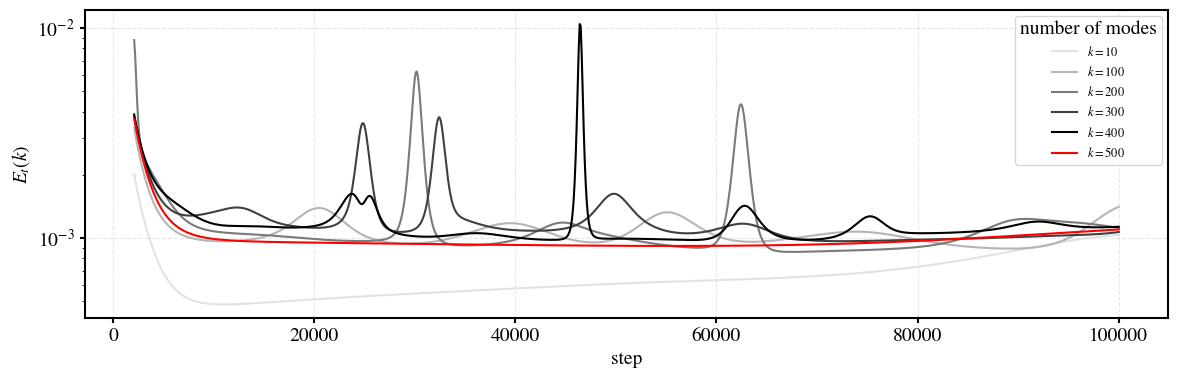

In [16]:
# Appendix Figure 5: E_t(k) convergence trajectories
# Compute E_matrix[k-1, pair] for the WD alpha=2 run from step 2000 onward
run_target = runs["wd_alpha3"]
checkpoint_paths = run_target["checkpoint_paths"]
X_diag_E = get_subset(run_target["X_train_jax"], DIAG_N_SUB, cell_key(6))

K_MAX = 500
start_step = 2000
start_idx = next(
    i for i, p in enumerate(checkpoint_paths)
    if int(p.stem.split("_")[-1]) >= start_step
)
n_pairs = len(checkpoint_paths) - 1 - start_idx
E_matrix = onp.zeros((K_MAX, n_pairs))

params_prev = load_checkpoint_to_jax(checkpoint_paths[start_idx])
J_prev = compute_jacobian(params_prev, X_diag_E, JAC_CHUNK_SIZE).astype(LINALG_DTYPE)
K_prev = compute_ntk(J_prev)
V_prev = compute_V_k(J_prev, K_prev, K_MAX).astype(LINALG_DTYPE)

for pair_idx in tqdm(range(n_pairs), desc="Computing E(k) across pairs"):
    path_next = checkpoint_paths[start_idx + pair_idx + 1]
    params_next = load_checkpoint_to_jax(path_next)
    J_next = compute_jacobian(params_next, X_diag_E, JAC_CHUNK_SIZE).astype(LINALG_DTYPE)
    K_next = compute_ntk(J_next)
    V_next = compute_V_k(J_next, K_next, K_MAX).astype(LINALG_DTYPE)

    for k in range(1, K_MAX + 1):
        V_a = V_prev[:, :k]
        V_b = V_next[:, :k]
        overlap = jnp.linalg.norm(V_a.T @ V_b) ** 2
        drift = jnp.sqrt(jnp.maximum(0.0, 1.0 - overlap / k))
        E_matrix[k - 1, pair_idx] = float(drift)

    V_prev = V_next
    K_prev = K_next
    del J_next, K_next, V_next, params_next

pair_steps = onp.array([
    int(checkpoint_paths[start_idx + i + 1].stem.split("_")[-1])
    for i in range(n_pairs)
])

selected_k = [10, 100, 200, 300, 400]
colors = plt.cm.Greys(onp.linspace(0.2, 1.0, len(selected_k)))

fig, ax = plt.subplots(figsize=(12, 4))
set_spine_width(ax)

for k, color in zip(selected_k, colors):
    ax.plot(pair_steps, E_matrix[k - 1, :], color=color, label=f"$k={k}$")
ax.plot(pair_steps, E_matrix[-1, :], color="red", label="$k=500$")

ax.set_xlabel("step")
ax.set_ylabel("$E_{t}(k)$")
ax.set_yscale("log")
ax.legend(loc="best", title="number of modes", fontsize=9)
ax.grid(True, ls="--", alpha=0.3)

fig.tight_layout()
plt.show()